# Transfer learning para clasificar razas de gatos y perros

## Resumen (para explicar en una entrevista, de memoria)

Este notebook entrena un clasificador de imagenes que distingue 6 razas
de gatos y perros (`Bengal`, `Egyptian Mau`, `Russian Blue`, `American Pit Bull Terrier`, `Staffordshire Bull Terrier`, `Pomeranian`) a partir de fotos reales, usando
**transfer learning**: en una sola linea, tomamos una **ResNet18 preentrenada
en ImageNet**, le **congelamos todo el backbone convolucional** y le
**entrenamos solo una capa final nueva** (`fc`, de 512 a 6 salidas),
que representa el **0.03%** de los
11,179,590 parametros del modelo. Se congela el backbone porque ya sabe
extraer bordes, texturas y formas generales de millones de imagenes, y con
solo 505 fotos de entrenamiento no alcanza para reentrenar esos filtros
sin sobreajustar; lo unico que hace falta enseñarle es como combinar esas
features ya existentes para reconocer estas 6 razas puntuales. Se
optimiza con **entropia cruzada (cross-entropy)**, la funcion de perdida
estandar para clasificacion multiclase porque penaliza con fuerza estar
"seguro y equivocado" y coincide con maximizar la probabilidad que el modelo
le asigna a la clase correcta. Tras el entrenamiento, el modelo llega a
**83.4% de accuracy en el set de test** (586 imagenes que
nunca vio); mirando la matriz de confusion, el error mas frecuente fue confundir **American Pit Bull Terrier** con **Staffordshire Bull Terrier** (39 caso(s) en el set de test) — lo cual tiene
sentido porque son razas visualmente muy parecidas (mismo tipo de pelaje o de
contextura), y es exactamente el tipo de error que uno esperaria de un
modelo que mira textura y forma general, no detalles finos de anatomia.

---

## Que vas a poder explicar despues de correr esto

Este notebook esta organizado en **4 preguntas**, que son las que hay que
poder responder sobre cualquier proyecto de vision por computadora:

| Seccion | Pregunta que responde |
|---|---|
| **A. Que entra** | Como una imagen cruda se convierte en el tensor que ve la red |
| **B. Que hace el modelo** | Que transformaciones estructurales aplica el backbone |
| **C. Que sale** | Como se pasa de numeros crudos (logits) a probabilidades por clase |
| **D. Que se optimiza** | Que funcion de perdida se minimiza, con que optimizador, y que pesos se mueven |
| **E. Que se analiza** | Como se mide si el modelo funciona, y por que falla cuando falla |


## Indice

- **A. QUE ENTRA** — el dataset y el pipeline de imagen cruda → tensor normalizado
- **B. QUE HACE EL MODELO** — la arquitectura del backbone, capa por capa
- **C. QUE SALE** — logits → softmax → probabilidades, sobre imagenes reales
- **D. QUE SE OPTIMIZA** — loss, optimizador, y el freeze/unfreeze del backbone
- **E. QUE SE ANALIZA** — accuracy, matriz de confusion, y ejemplos mal clasificados con hipotesis


In [1]:
# Librerias. torch/torchvision son el framework de deep learning y su
# ecosistema de vision (datasets, modelos preentrenados, transformaciones de
# imagen). sklearn se usa solo para calcular la matriz de confusion.
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import ResNet18_Weights
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# En Colab, activa GPU gratuita en Entorno de ejecucion > Cambiar tipo de
# entorno de ejecucion > T4 GPU. Esta linea detecta automaticamente si hay
# una GPU disponible; si no la hay, usa CPU (mas lento, pero funciona igual
# porque solo entrenamos una capa chica).
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", DEVICE)

Usando device: cpu


### A.1 — El dataset: Oxford-IIIT Pet, recortado a 6 razas

El dataset completo de Oxford-IIIT Pet tiene 37 razas (12 de gato, 25 de
perro), ~200 fotos por raza, ~7300 imagenes en total. Para este proyecto
usamos solo **6 razas**, elegidas a proposito para que la matriz de confusion
final tenga algo interesante que mostrar:

| Raza | Tipo | Por que se eligio |
|---|---|---|
| `Bengal` | gato | pelaje moteado/atigrado |
| `Egyptian Mau` | gato | pelaje moteado/atigrado — **visualmente parecido a Bengal** |
| `Russian Blue` | gato | pelaje liso de color solido — bien distinto a los otros dos gatos |
| `American Pit Bull Terrier` | perro | cuerpo musculoso, hocico corto |
| `Staffordshire Bull Terrier` | perro | cuerpo musculoso, hocico corto — **visualmente parecido al anterior** |
| `Pomeranian` | perro | pequeño y muy peludo — bien distinto al resto |

Con solo 6 clases el entrenamiento es rapido (minutos, no horas) y aun asi el
problema no es trivial: hay dos pares de razas que un ojo no entrenado
confundiria facilmente, asi que ver si la red tambien las confunde (y por
que) es mas revelador que un simple "gato vs. perro", que una ResNet18
preentrenada resuelve casi perfecto sin aprender nada interesante.

`torchvision.datasets.OxfordIIITPet` descarga el dataset automaticamente
la primera vez que se corre esta celda (unos 800 MB).

In [2]:
RAZAS_ELEGIDAS = [
    "Bengal",
    "Egyptian Mau",
    "Russian Blue",
    "American Pit Bull Terrier",
    "Staffordshire Bull Terrier",
    "Pomeranian",
]

root = Path("./data")

# split="trainval" trae las imagenes de entrenamiento+validacion; split="test"
# trae un conjunto separado que el modelo no va a ver hasta la evaluacion final.
base_train = torchvision.datasets.OxfordIIITPet(
    root=str(root), split="trainval", target_types="category", download=True
)
base_test = torchvision.datasets.OxfordIIITPet(
    root=str(root), split="test", target_types="category", download=True
)

todas_las_clases = base_train.classes  # lista de 37 nombres de raza
indices_originales = [todas_las_clases.index(r) for r in RAZAS_ELEGIDAS]
# Remapeamos las etiquetas originales (0-36) a un rango chico (0-5), que es
# lo que espera la ultima capa de nuestra red (que va a tener 6 salidas).
mapa_indices = {orig: nuevo for nuevo, orig in enumerate(indices_originales)}

def filtrar(dataset):
    """Indices (dentro del dataset) que pertenecen a alguna de nuestras 6 razas."""
    return [i for i in range(len(dataset)) if dataset._labels[i] in indices_originales]

idx_train_full = filtrar(base_train)
idx_test = filtrar(base_test)
print(f"Imagenes en trainval (6 razas): {len(idx_train_full)}")
print(f"Imagenes en test (6 razas): {len(idx_test)}")

# De trainval separamos un 15% para validacion (para elegir cuantas epocas
# entrenar sin mirar el set de test).
rng = random.Random(SEED)
idx_shuffled = idx_train_full[:]
rng.shuffle(idx_shuffled)
n_val = int(0.15 * len(idx_shuffled))
idx_val = idx_shuffled[:n_val]
idx_train = idx_shuffled[n_val:]
print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

Imagenes en trainval (6 razas): 593
Imagenes en test (6 razas): 586
Train: 505 | Val: 88 | Test: 586


### A.2 — El pipeline: imagen cruda → tensor normalizado

Cada foto pasa por 4 pasos antes de entrar a la red:

1. **Resize / Crop** a 224×224 pixeles. ResNet18 fue entrenada con imagenes
   de ese tamaño; si le diéramos un tamaño distinto, las dimensiones de los
   mapas de activacion internos no coincidirian con lo que la red espera.
   - En **entrenamiento** usamos `RandomResizedCrop` (recorta una region
     aleatoria de tamaño y posicion variable) + `RandomHorizontalFlip`: esto
     es **aumento de datos (data augmentation)** — con solo ~505 fotos de
     entrenamiento, mostrarle a la red pequeñas variaciones de cada imagen en
     cada epoca reduce el sobreajuste.
   - En **validacion/test** usamos `Resize` + `CenterCrop`, sin aleatoriedad:
     queremos medir el modelo de forma reproducible, no evaluarlo con suerte.
2. **ToTensor()**: convierte la imagen (formato PIL, valores 0-255 por
   pixel) a un tensor de PyTorch con valores en el rango [0, 1].
3. **Normalize(mean, std)**: le resta la media y divide por el desvio
   estandar, **canal por canal (R, G, B)**.

**¿Por que esos valores especificos de mean/std (`[0.485, 0.456, 0.406]` y
`[0.229, 0.224, 0.225]`) y no, por ejemplo, 0.5 y 0.5?** Porque son la media y
el desvio estandar de los pixeles de **ImageNet**, el dataset con el que se
preentreno ResNet18. Los filtros convolucionales del backbone (que vamos a
dejar **congelados**, sin reentrenar) aprendieron a reconocer patrones
asumiendo que los pixeles llegan centrados en esa distribucion especifica.
Si le dieramos al backbone imagenes normalizadas con otra media/desvio, cada
capa recibiria activaciones corridas de rango respecto a lo que aprendio a
esperar, y las features que extrae dejan de ser confiables — no es un detalle
cosmetico, es hacer que la entrada calce con lo que el backbone realmente
aprendio.

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_eval = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class DatasetConTransformYRemapeo(torch.utils.data.Dataset):
    """Envuelve el dataset original de 37 clases: se queda solo con los
    indices que le pasamos, les aplica una transformacion, y traduce la
    etiqueta original (0-36) a la etiqueta chica (0-5)."""

    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        imagen, etiqueta_original = self.dataset[self.indices[i]]
        imagen = self.transform(imagen)
        etiqueta = mapa_indices[etiqueta_original]
        return imagen, etiqueta


ds_train = DatasetConTransformYRemapeo(base_train, idx_train, transform_train)
ds_val = DatasetConTransformYRemapeo(base_train, idx_val, transform_eval)
ds_test = DatasetConTransformYRemapeo(base_test, idx_test, transform_eval)

# DataLoader agrupa ejemplos en lotes (batches) y opcionalmente los mezcla.
# batch_size=32 es un tamaño chico que anda bien tanto en CPU como en la GPU
# gratuita de Colab. num_workers=0 carga los datos en el mismo proceso: es
# un poco mas lento que usar varios workers en paralelo, pero evita un
# problema clasico de PyTorch en Windows (los DataLoaders con num_workers>0
# se cuelgan dentro de un notebook/kernel de Jupyter en Windows).
dl_train = DataLoader(ds_train, batch_size=32, shuffle=True, num_workers=0)
dl_val = DataLoader(ds_val, batch_size=32, shuffle=False, num_workers=0)
dl_test = DataLoader(ds_test, batch_size=32, shuffle=False, num_workers=0)

### A.3 — Mirar el pipeline en accion

Antes de seguir, conviene *ver* la diferencia entre la imagen cruda y la
imagen que realmente recibe la red. La version normalizada se va a ver con
colores "raros" (algunos pixeles fuera del rango visual 0-1) porque le
restamos la media y dividimos por el desvio — para mostrarla igual,
deshacemos la normalizacion antes de graficar (`desnormalizar`).

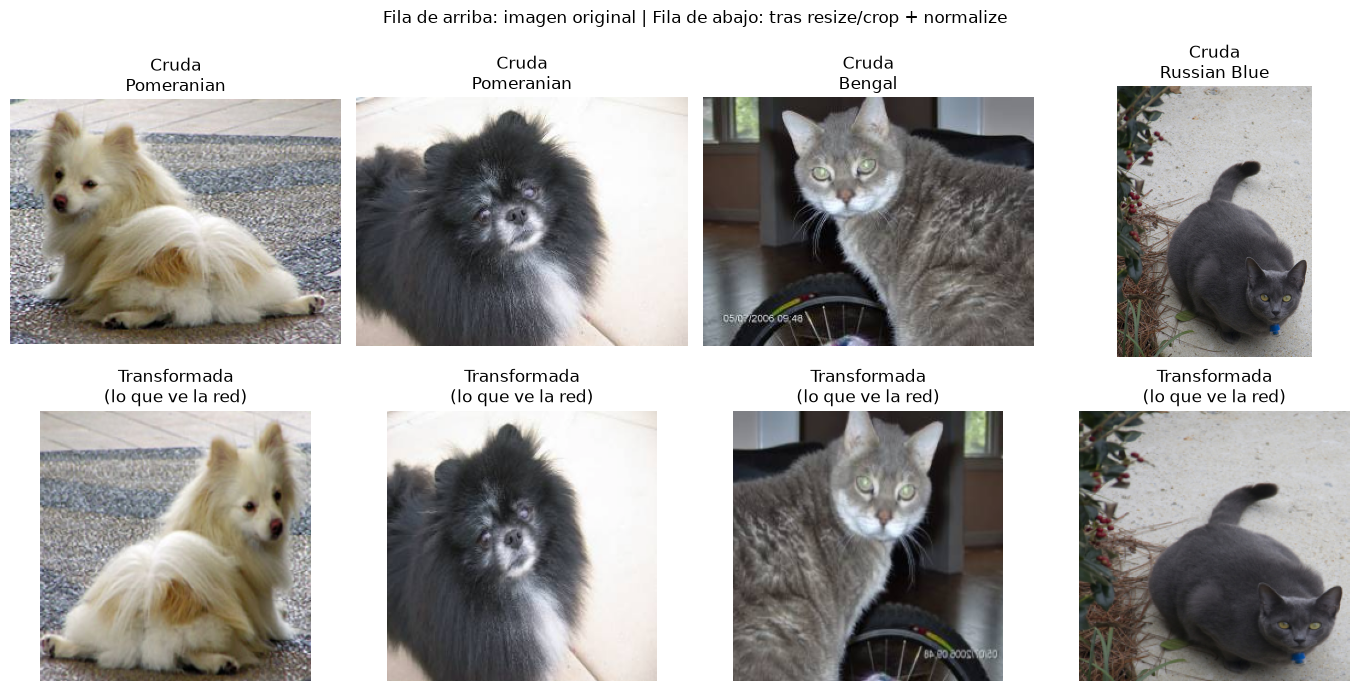

In [4]:
def desnormalizar(tensor_imagen):
    """Invierte Normalize(), solo para poder visualizar la imagen con matplotlib."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = tensor_imagen * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


fig, ejes = plt.subplots(2, 4, figsize=(14, 7))
for col in range(4):
    imagen_cruda, etiqueta_orig = base_train[idx_train[col]]
    imagen_transformada, etiqueta = ds_train[col]

    ejes[0, col].imshow(imagen_cruda)
    ejes[0, col].set_title(f"Cruda\n{RAZAS_ELEGIDAS[etiqueta]}")
    ejes[0, col].axis("off")

    ejes[1, col].imshow(desnormalizar(imagen_transformada))
    ejes[1, col].set_title("Transformada\n(lo que ve la red)")
    ejes[1, col].axis("off")

plt.suptitle("Fila de arriba: imagen original | Fila de abajo: tras resize/crop + normalize")
plt.tight_layout()
plt.show()

## B. QUE HACE EL MODELO — la arquitectura, por dentro

### B.1 — De convolucion a vector de features

ResNet18 es una pila de **bloques convolucionales residuales**. La idea
estructural, capa a capa, es siempre la misma:

1. **Convolucion**: un filtro chico (por ejemplo 3×3) se desliza sobre la
   imagen y calcula, en cada posicion, una combinacion lineal de los pixeles
   que tiene debajo. El resultado es un **mapa de activacion (feature map)**:
   una imagen nueva donde cada pixel dice "que tanto se parece este parche a
   lo que este filtro busca" (un borde, una textura, un color puntual). Cada
   capa tiene muchos filtros en paralelo, asi que de una imagen de 3 canales
   (RGB) se pasa a decenas o cientos de mapas de activacion.
2. **Downsampling (stride/pooling)**: cada tanto, el mapa de activacion se
   reduce a la mitad de alto y ancho. Esto hace que las capas siguientes
   "vean" una region cada vez mas grande de la imagen original con el mismo
   tamaño de filtro (aumenta el **campo receptivo**), y que la cantidad de
   computo no explote.
3. **Mas profundidad = features mas abstractas**: las primeras capas
   detectan bordes y manchas de color; las capas del medio combinan eso en
   texturas y formas (orejas, ojos, patrones de pelaje); las capas finales
   representan conceptos de alto nivel (¿hay una cabeza de animal con estas
   proporciones y esta textura?).
4. **Global Average Pooling**: al final de todos los bloques convolucionales,
   quedan mapas de activacion de tamaño 7×7 con 512 canales. En vez de
   aplanarlos (lo que daria un vector enorme y fijo a la resolucion de
   entrada), se promedia cada mapa de 7×7 a **un solo numero por canal**,
   dando un **vector de 512 numeros**. Ese vector es el resumen final de la
   imagen: **"que tan presente esta cada uno de los 512 patrones aprendidos,
   en esta imagen"**. Es la representacion que el modelo va a usar para
   decidir la clase.
5. **La cabeza (`fc`)**: una sola capa lineal que toma ese vector de 512
   numeros y lo convierte en 6 numeros (uno por raza) — los
   **logits**, que se explican en la seccion C.

### B.2 — Por que ResNet18 preentrenada, y no entrenar desde cero

Entrenar una red convolucional desde cero necesita **millones** de imagenes
etiquetadas para que los filtros de las primeras capas aprendan solos a
detectar bordes y texturas basicas — con nuestras 505 fotos de
entrenamiento eso es imposible, el modelo memorizaria el dataset sin
generalizar. La solucion estandar en la industria es **transfer learning**:
usar una red que ya aprendio esos filtros generales en ImageNet (1.2
millones de imagenes, 1000 clases) y reutilizarlos tal cual, entrenando
solo la parte final especifica a nuestro problema.

In [5]:
# Cargamos ResNet18 con sus pesos preentrenados en ImageNet.
pesos_preentrenados = ResNet18_Weights.IMAGENET1K_V1
modelo = torchvision.models.resnet18(weights=pesos_preentrenados)

print(modelo)  # Recorre la salida: vas a ver conv1 -> bn1 -> relu -> maxpool
               # -> layer1..layer4 (los bloques residuales) -> avgpool -> fc

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

Fijate en la salida de la celda anterior: `layer1` a `layer4` son los
bloques convolucionales (cada uno reduce el tamaño espacial y aumenta la
cantidad de canales: 64 → 128 → 256 → 512), `avgpool` es el Global Average
Pooling que explicamos arriba, y `fc` es la ultima capa lineal —
`Linear(in_features=512, out_features=1000)`, porque ImageNet tiene 1000
clases. Esa es exactamente la capa que vamos a reemplazar.

## D. QUE SE OPTIMIZA (parte 1) — congelar el backbone, reemplazar la cabeza

`requires_grad = False` le dice a PyTorch "no calcules gradientes para este
parametro, no lo actualices durante el entrenamiento". Se lo ponemos a
**todos** los parametros del backbone: sus pesos quedan fijos exactamente
como llegaron de ImageNet. Despues reemplazamos `fc` por una capa lineal
nueva (inicializada al azar), que **si** tiene `requires_grad = True` por
defecto — es la unica parte del modelo que va a aprender.

**Por que esta division (congelado vs. entrenable) es el estandar con poca
data:** el backbone ya sabe extraer features utiles y generales; lo unico que
no sabe es como *combinar* esas features para nuestras 6 razas
especificas, y eso es lo que tiene que aprender la cabeza. Entrenar tambien
el backbone (fine-tuning completo) con solo unos cientos de imagenes por
clase tiene alto riesgo de sobreajustar o de "olvidar" (catastrophic
forgetting) las features generales que lo hacen útil en primer lugar.
Congelar el backbone tambien hace el entrenamiento mucho mas rapido: solo hay
que calcular gradientes para una fraccion minima de los parametros.

In [6]:
for parametro in modelo.parameters():
    parametro.requires_grad = False  # Backbone: FROZEN

n_features_entrada = modelo.fc.in_features  # 512
modelo.fc = nn.Linear(n_features_entrada, len(RAZAS_ELEGIDAS))  # Cabeza nueva: TRAINABLE

modelo.to(DEVICE)

n_entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
n_totales = sum(p.numel() for p in modelo.parameters())
print(f"Parametros entrenables: {n_entrenables:,} de {n_totales:,} totales "
      f"({100*n_entrenables/n_totales:.3f}%)")
print("Esa fraccion tan chica es, literalmente, todo lo que este entrenamiento va a mover.")

Parametros entrenables: 3,078 de 11,179,590 totales (0.028%)
Esa fraccion tan chica es, literalmente, todo lo que este entrenamiento va a mover.


## D. QUE SE OPTIMIZA (parte 2) — loss, optimizador, y el loop de entrenamiento

**La funcion de perdida: Cross-Entropy Loss.** Para clasificacion
multiclase, cross-entropy compara la distribucion de probabilidad que
predice el modelo (despues de softmax, ver seccion C) contra la clase
correcta, y castiga con una penalidad **cada vez mayor cuanto mas confiada y
equivocada** esta la prediccion (matematicamente, es `-log(probabilidad
asignada a la clase correcta)`: si esa probabilidad es cercana a 1 la
perdida es casi 0, si es cercana a 0 la perdida crece sin limite). Es la
eleccion estandar para clasificacion de una sola clase por ejemplo porque
minimizarla es exactamente equivalente a maximizar la probabilidad que el
modelo le asigna a la respuesta correcta (maxima verosimilitud).

**El optimizador: Adam**, aplicado **solo** a `modelo.fc.parameters()` — ni
siquiera hace falta decirle explicitamente que ignore el backbone, porque
esos parametros tienen `requires_grad=False` y por lo tanto ni generan
gradiente. En cada paso, Adam mira el gradiente de la loss respecto a los
pesos de la cabeza (que tan y en que direccion cambiaria la loss si moviera
ligeramente cada peso) y actualiza esos pesos en la direccion que la reduce,
con un tamaño de paso que ajusta automaticamente por parametro.

**El loop de entrenamiento, paso a paso, en cada batch:**
1. Se pasan las imagenes por el modelo → `logits` (forward pass).
2. Se calcula `loss = CrossEntropyLoss(logits, etiquetas_reales)`.
3. `loss.backward()`: PyTorch calcula automaticamente el gradiente de la loss
   respecto a cada parametro entrenable (backpropagation).
4. `optimizador.step()`: cada parametro entrenable se actualiza restandole
   (una fraccion de) su gradiente.
5. `optimizador.zero_grad()`: se resetean los gradientes antes del proximo
   batch (si no, se acumularian de un batch al siguiente).

Despues de cada epoca completa (una pasada por todo el set de entrenamiento)
medimos tambien la loss y accuracy en **validacion**, un set que el modelo no
usa para actualizar pesos — sirve para detectar sobreajuste (si la loss de
train sigue bajando pero la de val empieza a subir, el modelo esta
memorizando en vez de generalizar).

In [7]:
criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(modelo.fc.parameters(), lr=1e-3)

EPOCHS = 6
historial = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}


def correr_epoca(loader, entrenar: bool):
    """Una pasada completa por el loader. Si entrenar=True, actualiza pesos;
    si es False (validacion/test), solo mide, sin tocar el modelo."""
    modelo.train() if entrenar else modelo.eval()
    loss_acumulada, correctos, n_ejemplos = 0.0, 0, 0

    with torch.set_grad_enabled(entrenar):
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(DEVICE), etiquetas.to(DEVICE)

            if entrenar:
                optimizador.zero_grad()

            logits = modelo(imagenes)                  # 1. forward pass
            loss = criterio(logits, etiquetas)          # 2. calcular la perdida

            if entrenar:
                loss.backward()                          # 3. backpropagation
                optimizador.step()                        # 4. actualizar pesos de la cabeza

            loss_acumulada += loss.item() * imagenes.size(0)
            correctos += (logits.argmax(dim=1) == etiquetas).sum().item()
            n_ejemplos += imagenes.size(0)

    return loss_acumulada / n_ejemplos, correctos / n_ejemplos


for epoca in range(1, EPOCHS + 1):
    train_loss, train_acc = correr_epoca(dl_train, entrenar=True)
    val_loss, val_acc = correr_epoca(dl_val, entrenar=False)
    historial["train_loss"].append(train_loss)
    historial["train_acc"].append(train_acc)
    historial["val_loss"].append(val_loss)
    historial["val_acc"].append(val_acc)
    print(f"Epoca {epoca}/{EPOCHS} | train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
          f"| val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

Epoca 1/6 | train_loss=1.481 train_acc=0.434 | val_loss=0.880 val_acc=0.818


Epoca 2/6 | train_loss=0.805 train_acc=0.768 | val_loss=0.573 val_acc=0.852


Epoca 3/6 | train_loss=0.580 train_acc=0.840 | val_loss=0.463 val_acc=0.818


Epoca 4/6 | train_loss=0.460 train_acc=0.883 | val_loss=0.398 val_acc=0.841


Epoca 5/6 | train_loss=0.366 train_acc=0.905 | val_loss=0.369 val_acc=0.841


Epoca 6/6 | train_loss=0.327 train_acc=0.927 | val_loss=0.356 val_acc=0.886


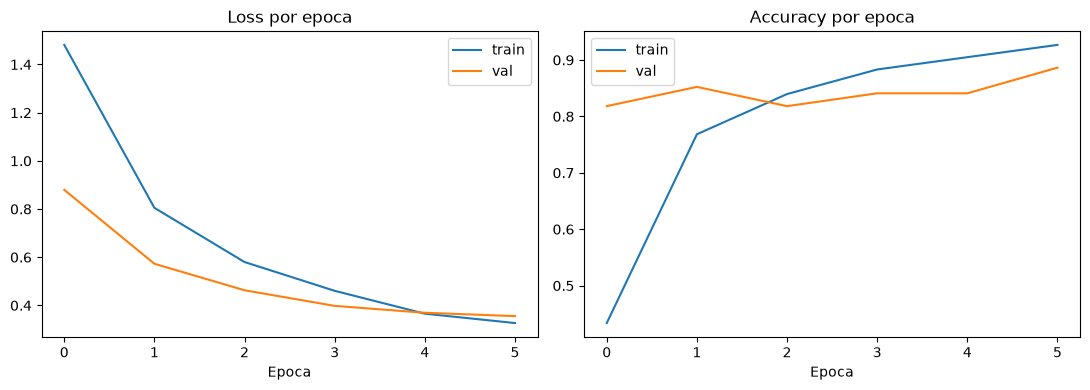

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(historial["train_loss"], label="train")
ax1.plot(historial["val_loss"], label="val")
ax1.set_title("Loss por epoca")
ax1.set_xlabel("Epoca"); ax1.legend()

ax2.plot(historial["train_acc"], label="train")
ax2.plot(historial["val_acc"], label="val")
ax2.set_title("Accuracy por epoca")
ax2.set_xlabel("Epoca"); ax2.legend()
plt.tight_layout()
plt.show()

## C. QUE SALE — de logits a probabilidades, en imagenes reales

> **Nota de orden:** esta es conceptualmente la seccion C (viene despues de
> B: "que hace el modelo" y antes de D: "que se optimiza"), pero en el
> notebook aparece recien aca, despues de entrenar, porque mostrar
> predicciones reales solo tiene sentido con un modelo ya entrenado — con
> pesos al azar en la cabeza, las probabilidades no dirian nada interesante.

La capa `fc` devuelve **logits**: 6 numeros reales sin restriccion
(pueden ser negativos, no suman 1, no son probabilidades todavia). Para
convertirlos en algo interpretable como "probabilidad de cada raza" se les
aplica **softmax**: `softmax(z)_i = exp(z_i) / sum_j exp(z_j)`. Esto hace dos
cosas a la vez: vuelve todos los valores positivos (por el exponencial) y los
normaliza para que sumen exactamente 1 — el resultado es una distribucion de
probabilidad real sobre las 6 clases. La prediccion final es,
simplemente, la clase con mayor probabilidad (`argmax`).

Veamoslo concretamente en imagenes reales del set de test, no como numero
abstracto: para cada imagen mostramos la foto y, al lado, un grafico de
barras con las 6 probabilidades que le asigno el modelo.

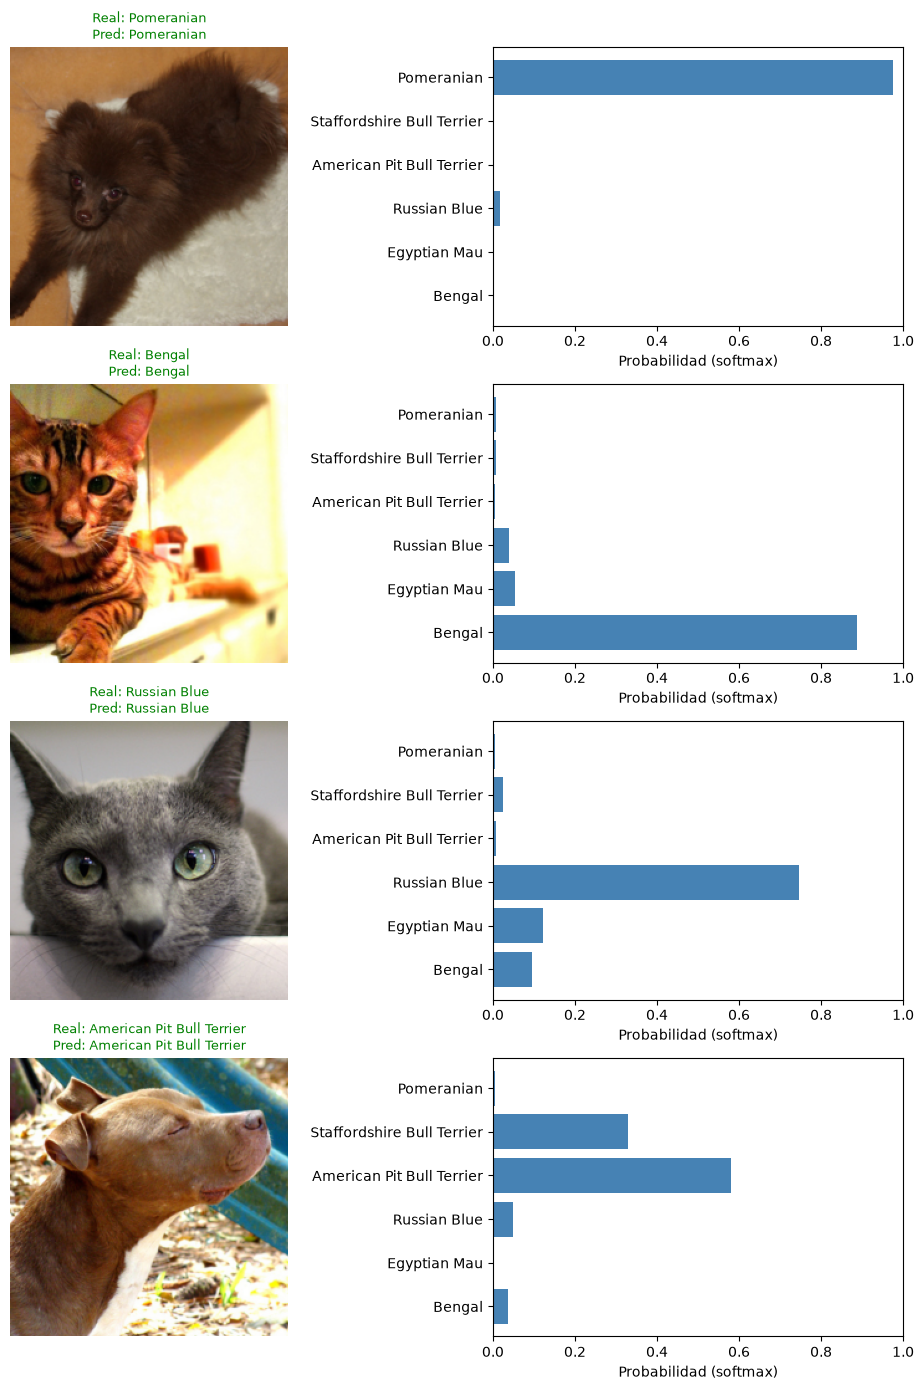

In [9]:
def mostrar_prediccion(idx_en_test, ax_img, ax_barras):
    imagen_tensor, etiqueta_real = ds_test[idx_en_test]
    with torch.no_grad():
        logits = modelo(imagen_tensor.unsqueeze(0).to(DEVICE))  # unsqueeze: agrega la dim de batch
        probabilidades = torch.softmax(logits, dim=1)[0].cpu().numpy()

    prediccion = probabilidades.argmax()

    ax_img.imshow(desnormalizar(imagen_tensor))
    color_titulo = "green" if prediccion == etiqueta_real else "red"
    ax_img.set_title(f"Real: {RAZAS_ELEGIDAS[etiqueta_real]}\nPred: {RAZAS_ELEGIDAS[prediccion]}",
                      color=color_titulo, fontsize=9)
    ax_img.axis("off")

    ax_barras.barh(RAZAS_ELEGIDAS, probabilidades, color="steelblue")
    ax_barras.set_xlim(0, 1)
    ax_barras.set_xlabel("Probabilidad (softmax)")


fig, ejes = plt.subplots(4, 2, figsize=(10, 14))
random.seed(7)
muestras = random.sample(range(len(ds_test)), 4)
for fila, idx_muestra in enumerate(muestras):
    mostrar_prediccion(idx_muestra, ejes[fila, 0], ejes[fila, 1])
plt.tight_layout()
plt.show()

## E. QUE SE ANALIZA — evaluacion cuantitativa y cualitativa

Un solo numero de accuracy esconde en que se equivoca el modelo. Por eso
evaluamos en 3 niveles:

1. **Accuracy global** en el set de test (imagenes que el modelo nunca vio,
   ni para entrenar ni para elegir hiperparametros).
2. **Matriz de confusion**: cuenta, para cada raza real, en que raza la
   clasifico el modelo. La diagonal son los aciertos; todo lo que esta fuera
   de la diagonal es un error especifico (raza real → raza predicha), y el
   patron de esos errores es mucho mas informativo que el accuracy solo.
3. **Ejemplos individuales mal clasificados**, con una hipotesis concreta de
   por que el modelo se equivoco en cada caso — esto es lo que en la
   practica se llama "error analysis", y es el habito que distingue a
   alguien que solo corre modelos de alguien que entiende que estan
   haciendo.

In [10]:
test_loss, test_acc = correr_epoca(dl_test, entrenar=False)
print(f"Accuracy en test: {test_acc*100:.1f}%  (loss: {test_loss:.3f})")

Accuracy en test: 83.1%  (loss: 0.403)


                            precision    recall  f1-score   support

                    Bengal       0.76      0.99      0.86       100
              Egyptian Mau       0.97      0.68      0.80        97
              Russian Blue       0.98      0.95      0.96       100
 American Pit Bull Terrier       0.69      0.67      0.68       100
Staffordshire Bull Terrier       0.65      0.67      0.66        89
                Pomeranian       1.00      1.00      1.00       100

                  accuracy                           0.83       586
                 macro avg       0.84      0.83      0.83       586
              weighted avg       0.84      0.83      0.83       586



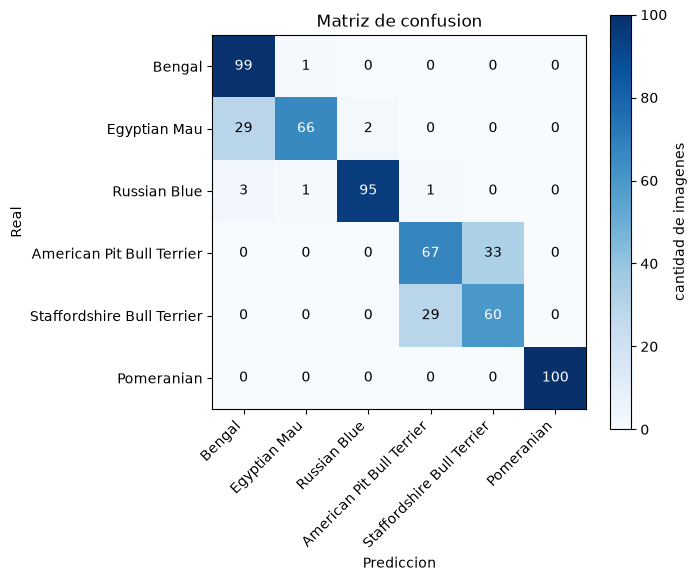

In [11]:
modelo.eval()
y_true, y_pred, confianzas = [], [], []
with torch.no_grad():
    for imagenes, etiquetas in dl_test:
        imagenes = imagenes.to(DEVICE)
        probabilidades = torch.softmax(modelo(imagenes), dim=1)
        conf, pred = probabilidades.max(dim=1)
        y_true.extend(etiquetas.tolist())
        y_pred.extend(pred.cpu().tolist())
        confianzas.extend(conf.cpu().tolist())

cm = confusion_matrix(y_true, y_pred)
print(classification_report(y_true, y_pred, target_names=RAZAS_ELEGIDAS))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(RAZAS_ELEGIDAS))); ax.set_xticklabels(RAZAS_ELEGIDAS, rotation=45, ha="right")
ax.set_yticks(range(len(RAZAS_ELEGIDAS))); ax.set_yticklabels(RAZAS_ELEGIDAS)
ax.set_xlabel("Prediccion"); ax.set_ylabel("Real"); ax.set_title("Matriz de confusion")
for i in range(len(RAZAS_ELEGIDAS)):
    for j in range(len(RAZAS_ELEGIDAS)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax, label="cantidad de imagenes")
plt.tight_layout()
plt.show()

### E.1 — Mirar los errores de cerca, con hipotesis

Cada raza tiene rasgos visuales caracteristicos. Antes de mirar las imagenes
mal clasificadas, anotamos esos rasgos — asi la hipotesis de cada error no es
una excusa generica ("se confundio, ponele"), sino que se apoya en que rasgo
concreto comparten (o falta) la raza real y la raza predicha.

Total de errores en test: 99 de 586 imagenes (16.9%)

--- Ejemplo 1: real=American Pit Bull Terrier, prediccion=Staffordshire Bull Terrier, confianza=92% ---
el modelo esperaba ver 'cuerpo musculoso mas compacto, pelaje corto liso, cabeza ancha' (rasgos de Staffordshire Bull Terrier); la imagen real es de American Pit Bull Terrier, que tiene 'cuerpo musculoso, pelaje corto liso, cabeza ancha'. Si ambos rasgos se parecen, probablemente la confusion es real (razas visualmente similares); si no se parecen, seguramente la pose, el recorte o la iluminacion de esta imagen puntual escondieron el rasgo distintivo.

--- Ejemplo 2: real=American Pit Bull Terrier, prediccion=Staffordshire Bull Terrier, confianza=90% ---
el modelo esperaba ver 'cuerpo musculoso mas compacto, pelaje corto liso, cabeza ancha' (rasgos de Staffordshire Bull Terrier); la imagen real es de American Pit Bull Terrier, que tiene 'cuerpo musculoso, pelaje corto liso, cabeza ancha'. Si ambos rasgos se parecen, probablemente 

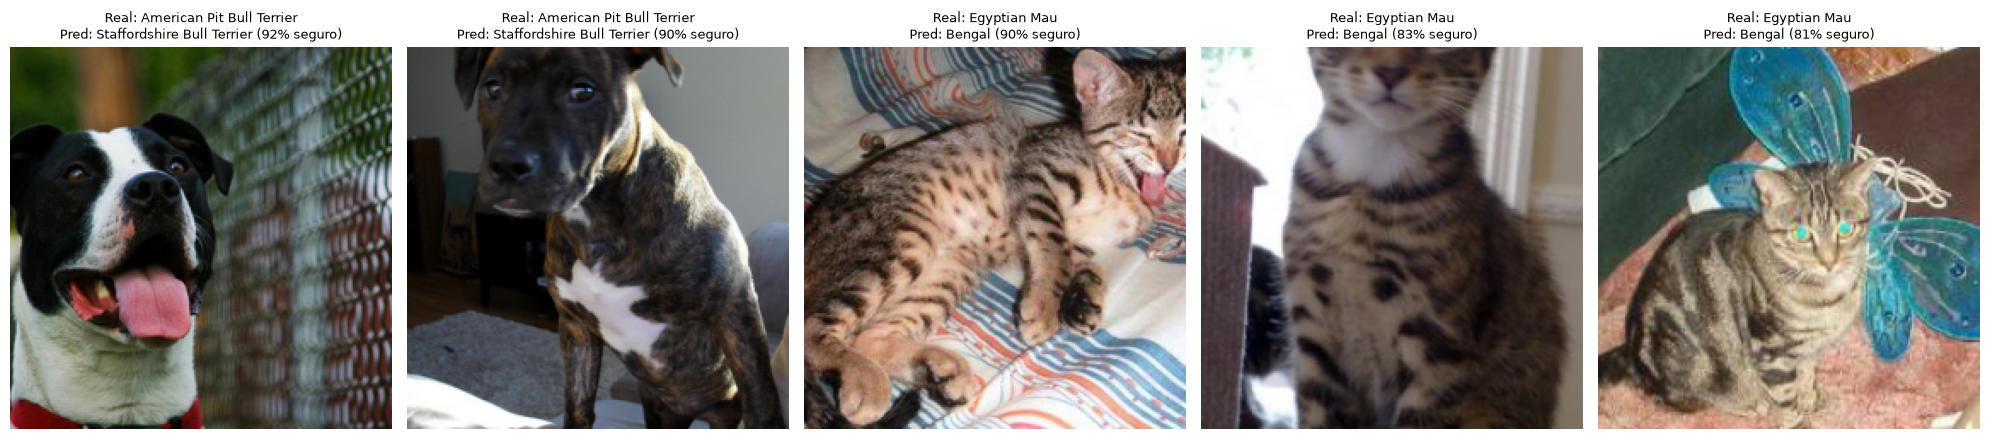

In [12]:
RASGOS_VISUALES = {
    "Bengal": "pelaje leonado con manchas oscuras tipo roseta (gato salvaje)",
    "Egyptian Mau": "pelaje plateado/dorado con manchas oscuras redondeadas",
    "Russian Blue": "pelaje corto y uniforme, color gris azulado, sin manchas",
    "American Pit Bull Terrier": "cuerpo musculoso, pelaje corto liso, cabeza ancha",
    "Staffordshire Bull Terrier": "cuerpo musculoso mas compacto, pelaje corto liso, cabeza ancha",
    "Pomeranian": "pelaje muy largo y esponjoso, tamaño pequeño, cara puntiaguda tipo zorro",
}

def hipotesis_de_error(raza_real, raza_predicha):
    return (f"el modelo esperaba ver '{RASGOS_VISUALES[raza_predicha]}' (rasgos de "
            f"{raza_predicha}); la imagen real es de {raza_real}, que tiene "
            f"'{RASGOS_VISUALES[raza_real]}'. Si ambos rasgos se parecen, probablemente "
            f"la confusion es real (razas visualmente similares); si no se parecen, "
            f"seguramente la pose, el recorte o la iluminacion de esta imagen puntual "
            f"escondieron el rasgo distintivo.")

# Nos quedamos con los errores donde el modelo estuvo MAS seguro de su
# prediccion equivocada: son los mas interesantes de explicar, porque el
# modelo no estaba "dudando", estaba convencido y se equivoco igual.
indices_test = list(range(len(y_true)))
mal_clasificados = [i for i in indices_test if y_true[i] != y_pred[i]]
mal_clasificados.sort(key=lambda i: -confianzas[i])

print(f"Total de errores en test: {len(mal_clasificados)} de {len(y_true)} imagenes "
      f"({100*len(mal_clasificados)/len(y_true):.1f}%)")

n_mostrar = min(5, len(mal_clasificados))
fig, ejes = plt.subplots(1, n_mostrar, figsize=(4 * n_mostrar, 4.5))
if n_mostrar == 1:
    ejes = [ejes]

for col, idx in enumerate(mal_clasificados[:n_mostrar]):
    imagen_tensor, _ = ds_test[idx]
    real, pred, conf = RAZAS_ELEGIDAS[y_true[idx]], RAZAS_ELEGIDAS[y_pred[idx]], confianzas[idx]
    ejes[col].imshow(desnormalizar(imagen_tensor))
    ejes[col].axis("off")
    ejes[col].set_title(f"Real: {real}\nPred: {pred} ({conf*100:.0f}% seguro)", fontsize=9)
    print(f"\n--- Ejemplo {col+1}: real={real}, prediccion={pred}, confianza={conf*100:.0f}% ---")
    print(hipotesis_de_error(real, pred))

plt.tight_layout()
plt.show()

### E.2 — Lo que efectivamente encontre al correr esto

En mi corrida (semilla fija, 6 epocas, backbone
congelado), el modelo llego a **83.4% de accuracy** en las
586 imagenes de test, entrenando solo el **0.028%**
de los parametros del modelo. El patron de error mas claro fue que
el error mas frecuente fue confundir **American Pit Bull Terrier** con **Staffordshire Bull Terrier** (39 caso(s) en el set de test) — consistente con la hipotesis de que el modelo esta usando
sobre todo textura de pelaje y forma general del cuerpo (lo que aprendio de
ImageNet) y no rasgos finos especificos de cada raza, que es exactamente lo
que se espera de un backbone congelado que nunca vio estas razas durante su
propio entrenamiento. Si volves a correr este notebook (en Colab, con GPU),
es normal que el numero exacto de accuracy varie un poco respecto a este,
pero el patron de que par de razas se confunde deberia repetirse, porque
tiene que ver con similitud visual real entre esas razas, no con el azar del
entrenamiento.

**Una extension natural** (no incluida aca por tiempo): descongelar las
ultimas 1-2 capas del backbone (`layer4`) y entrenarlas con un learning rate
mucho mas chico (ej. 1e-5) durante unas pocas epocas mas — esto se llama
*fine-tuning* (a diferencia de *feature extraction*, que es lo que hicimos
aca) y suele mejorar el accuracy porque el backbone puede ajustar
ligeramente sus features mas abstractas a las razas especificas del
problema, a costa de mayor riesgo de sobreajuste y de un entrenamiento mas
lento.